In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('innovize_final_ml.csv')

In [4]:
df.head()

,phy_fitness,diet_pref,act_level,sleep_hrs,mindfulness,career,gender,daily_avg_steps,daily_avg_calories,is_healthy
0,3.0,Vegan,Sedentary,7,10,Artist,1.0,2020.0,1831.0,0
1,4.0,Vegan,Lightly Active,7,1,Teacher,0.0,5154.0,2190.0,0
2,8.0,Vegetarian,Active,8,10,Freelancer,1.0,12363.0,2297.0,1
3,2.0,Pescatarian,Sedentary,8,7,Doctor,0.0,1664.0,1943.0,0
4,9.0,Pescatarian,Highly Active,5,7,Business,0.0,17680.0,3527.0,1


In [5]:
df.describe

<bound method NDFrame.describe of       phy_fitness    diet_pref       act_level  sleep_hrs  mindfulness  \
0             3.0        Vegan       Sedentary          7           10   
1             4.0        Vegan  Lightly Active          7            1   
2             8.0   Vegetarian          Active          8           10   
3             2.0  Pescatarian       Sedentary          8            7   
4             9.0  Pescatarian   Highly Active          5            7   
...           ...          ...             ...        ...          ...   
5995          7.0         Keto          Active          7            8   
5996          2.0         Keto       Sedentary          5            4   
5997          2.0         Keto       Sedentary          7            7   
5998          7.0        Vegan          Active          9            2   
5999          7.0  Pescatarian          Active          8            3   

          career  gender  daily_avg_steps  daily_avg_calories  is_healthy  
0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   phy_fitness         5997 non-null   float64
 1   diet_pref           5996 non-null   object 
 2   act_level           5994 non-null   object 
 3   sleep_hrs           6000 non-null   int64  
 4   mindfulness         6000 non-null   int64  
 5   career              5996 non-null   object 
 6   gender              5999 non-null   float64
 7   daily_avg_steps     5989 non-null   float64
 8   daily_avg_calories  5986 non-null   float64
 9   is_healthy          6000 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 468.9+ KB


In [7]:
df.isnull().sum()

phy_fitness            3
diet_pref              4
act_level              6
sleep_hrs              0
mindfulness            0
career                 4
gender                 1
daily_avg_steps       11
daily_avg_calories    14
is_healthy             0
dtype: int64

In [8]:
numerical_cols = ["phy_fitness", "gender", "daily_avg_steps", "daily_avg_calories"]
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

categorical_cols = ["diet_pref", "act_level", "career"]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df.isnull().sum()

phy_fitness           0
diet_pref             0
act_level             0
sleep_hrs             0
mindfulness           0
career                0
gender                0
daily_avg_steps       0
daily_avg_calories    0
is_healthy            0
dtype: int64

In [10]:
df = pd.get_dummies(df, columns=["diet_pref", "act_level", "career"], drop_first=True)
df.head()

,phy_fitness,sleep_hrs,mindfulness,gender,daily_avg_steps,daily_avg_calories,is_healthy,diet_pref_Non-Vegetarian,diet_pref_Pescatarian,diet_pref_Vegan,...,act_level_Sedentary,career_Business,career_Doctor,career_Engineer,career_Freelancer,career_Lawyer,career_Manager,career_Nurse,career_Scientist,career_Teacher
0,3.0,7,10,1.0,2020.0,1831.0,0,False,False,True,...,True,False,False,False,False,False,False,False,False,False
1,4.0,7,1,0.0,5154.0,2190.0,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2,8.0,8,10,1.0,12363.0,2297.0,1,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2.0,8,7,0.0,1664.0,1943.0,0,False,True,False,...,True,False,True,False,False,False,False,False,False,False
4,9.0,5,7,0.0,17680.0,3527.0,1,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["phy_fitness", "sleep_hrs", "mindfulness", "daily_avg_steps", "daily_avg_calories"]] = \
    scaler.fit_transform(df[["phy_fitness", "sleep_hrs", "mindfulness", "daily_avg_steps", "daily_avg_calories"]])

df.head()


,phy_fitness,sleep_hrs,mindfulness,gender,daily_avg_steps,daily_avg_calories,is_healthy,diet_pref_Non-Vegetarian,diet_pref_Pescatarian,diet_pref_Vegan,...,act_level_Sedentary,career_Business,career_Doctor,career_Engineer,career_Freelancer,career_Lawyer,career_Manager,career_Nurse,career_Scientist,career_Teacher
0,-0.845195,-0.007309,1.539919,1.0,-1.270825,-0.876875,0,False,False,True,...,True,False,False,False,False,False,False,False,False,False
1,-0.498882,-0.007309,-1.589056,0.0,-0.703046,-0.314275,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2,0.886370,0.700052,1.539919,1.0,0.602991,-0.146592,1,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,-1.191508,0.700052,0.496928,0.0,-1.335321,-0.701356,0,False,True,False,...,True,False,True,False,False,False,False,False,False,False
4,1.232683,-1.422032,0.496928,0.0,1.566259,1.780978,1,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [12]:
df = df.drop(columns=["gender"] + [col for col in df.columns if col.startswith("career_")])


In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=["is_healthy"])
y = df["is_healthy"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")



Train-Test Split Complete!
Training Samples: 4800, Testing Samples: 1200


In [ ]:
from sklearn.svm import SVC


svm_model = SVC(kernel="rbf", random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")


SVM Accuracy: 0.9933


In [17]:
%pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 5.6 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.4 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


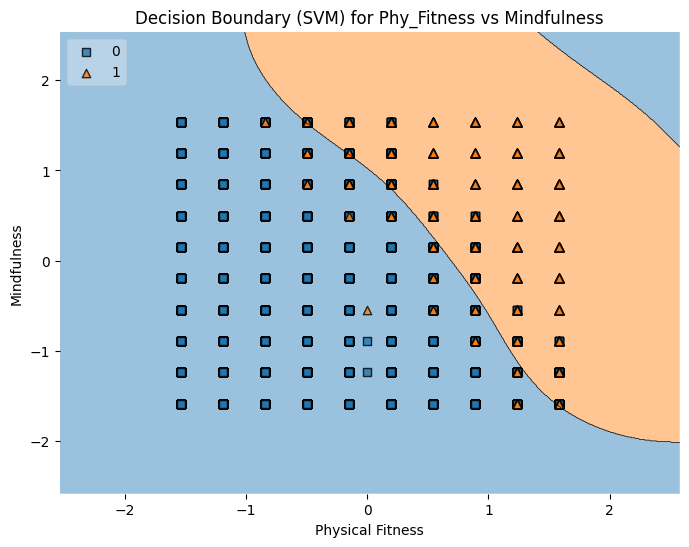

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

# Select only phy_fitness and mindfulness for visualization
X_vis = X_train[["phy_fitness", "mindfulness"]].values
y_vis = y_train.values

# Train SVM again with only these two features
svm_vis = SVC(kernel="rbf", random_state=42)
svm_vis.fit(X_vis, y_vis)

# Plot Decision Boundary
plt.figure(figsize=(8, 6))
plot_decision_regions(X_vis, y_vis, clf=svm_vis, legend=2)
plt.xlabel("Physical Fitness")
plt.ylabel("Mindfulness")
plt.title("Decision Boundary (SVM) for Phy_Fitness vs Mindfulness")
plt.show()
